### Referrel Porgram A/B Analysis
End-to-end analysis of a user referral program using Python and pandas — evaluating pre/post launch impact on user growth, transaction volume, and revenue with actionable recommendations for the Growth team.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import os

In [4]:
referral  = pd.read_csv(os.path.join('data', 'referral.csv'))
referral.head()

,user_id,date,country,money_spent,is_referral,device_id
0,2,2015-10-03,FR,65,0,EVDCJTZMVMJDG
1,3,2015-10-03,CA,54,0,WUBZFTVKXGQQX
2,6,2015-10-03,FR,35,0,CBAPCJRTFNUJG
3,7,2015-10-03,UK,73,0,PRGXJZAJKMXRH
4,7,2015-10-03,MX,35,0,PRGXJZAJKMXRH


In [5]:
print('Dataset Information:', referral.info())

<class 'pandas.DataFrame'>
RangeIndex: 97341 entries, 0 to 97340
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      97341 non-null  int64
 1   date         97341 non-null  str  
 2   country      97341 non-null  str  
 3   money_spent  97341 non-null  int64
 4   is_referral  97341 non-null  int64
 5   device_id    97341 non-null  str  
dtypes: int64(3), str(3)
memory usage: 4.5 MB
Dataset Information: None


In [7]:
print('Dataset Description:\n', referral.describe())

Dataset Description:
             user_id   money_spent   is_referral
count  97341.000000  97341.000000  97341.000000
mean    6354.801029     44.692360      0.287823
std     5682.991186     22.791839      0.452751
min        1.000000     10.000000      0.000000
25%     2020.000000     27.000000      0.000000
50%     4053.000000     42.000000      0.000000
75%    10286.000000     59.000000      1.000000
max    20000.000000    220.000000      1.000000


In [22]:
print('Dataset Duplicates:', referral.duplicated(keep=False).sum())
# Display duplicate rows
print(referral[referral.duplicated(keep=False)])

Dataset Duplicates: 48
       user_id        date country  money_spent  is_referral      device_id
1524      2557  2015-10-03      DE           37            0  IACHUGISDMNKC
1525      2557  2015-10-03      DE           37            0  IACHUGISDMNKC
2707      4463  2015-10-03      DE           21            0  XLXGQZAPCDEFS
2708      4463  2015-10-03      DE           21            0  XLXGQZAPCDEFS
9454      4771  2015-10-07      FR           54            0  KNAEYOYYDVDJY
9455      4771  2015-10-07      FR           54            0  KNAEYOYYDVDJY
10056     2466  2015-10-08      US           23            0  FIBYLEPRDNHPO
10057     2466  2015-10-08      US           23            0  FIBYLEPRDNHPO
15180      674  2015-10-11      MX           40            0  NOPCAMOTUQMPM
15181      674  2015-10-11      MX           40            0  NOPCAMOTUQMPM
18120     1297  2015-10-12      UK           42            0  PNKHZRKFYGKWL
18121     1297  2015-10-12      UK           42            0  PNK

In [23]:
print('Dataset Duplicates with is_referral=1:', (referral.duplicated(keep=False) & (referral['is_referral']==1)).sum())
print(referral[referral.duplicated(keep=False) & (referral['is_referral']==1)])

Dataset Duplicates with is_referral=1: 4
       user_id        date country  money_spent  is_referral      device_id
54897    19232  2015-11-02      US           55            1  GNCXTIWJQTRWJ
54898    19232  2015-11-02      US           55            1  GNCXTIWJQTRWJ
87087    14066  2015-11-21      UK           32            1  FFZNNVFETQYCF
87088    14066  2015-11-21      UK           32            1  FFZNNVFETQYCF


In [25]:
print('referral distribution:\n', referral['is_referral'].value_counts(normalize=True))

referral distribution:
 is_referral
0    0.712177
1    0.287823
Name: proportion, dtype: float64


In [36]:
pd.crosstab(referral['is_referral'], referral[(referral['money_spent'] > 50) & (referral['money_spent'] < 100)]['money_spent']
            ,normalize='index'
            ).round(2)

money_spent,51,52,53,54,55,56,57,58,59,60,...,90,91,92,93,94,95,96,97,98,99
is_referral,,,,,,,,,,,,,,,,,,,,,
0,0.05,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.03,0.03,...,0.01,0.01,0.01,0.01,0.01,0.01,0.00,0.00,0.00,0.00
1,0.04,0.04,0.04,0.04,0.04,0.04,0.04,0.03,0.03,0.03,...,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01


In [5]:
referral = referral.drop_duplicates()

In [38]:
print('Re check referral distribution:\n', referral['is_referral'].value_counts(normalize=True))

Re check referral distribution:
 is_referral
0    0.712126
1    0.287874
Name: proportion, dtype: float64


In [6]:
referral['date'] = pd.to_datetime(referral['date'])
referral['date'].max(), referral['date'].min()  

(Timestamp('2015-11-27 00:00:00'), Timestamp('2015-10-03 00:00:00'))

In [7]:
df_pre = referral[referral['date'] < '2015-10-31']
df_post = referral[referral['date'] >= '2015-10-31']

In [8]:
control_pre = df_pre.groupby(['is_referral', 'date'])\
    .agg(total_users=('user_id', 'nunique'),
         total_spent=('money_spent', 'sum'),
         avg_spent=('money_spent', 'mean'))\
    .reset_index()



In [9]:
control_post = df_post[df_post['is_referral']==0].groupby(['is_referral', 'date'])\
    .agg(total_users=('user_id', 'nunique'),
         total_spent=('money_spent', 'sum'),
         avg_spent=('money_spent', 'mean'))\
    .reset_index()
test_post = df_post[df_post['is_referral']==1].groupby(['is_referral', 'date'])\
    .agg(total_users=('user_id', 'nunique'),
         total_spent=('money_spent', 'sum'),
         avg_spent=('money_spent', 'mean'))\
    .reset_index()

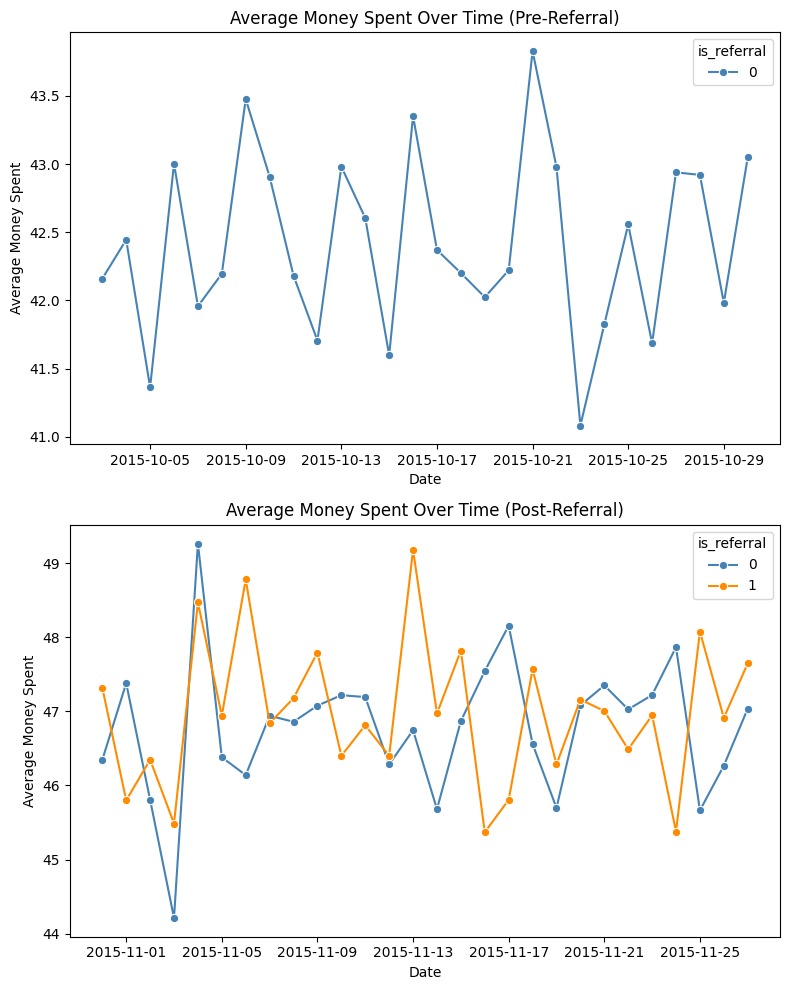

In [77]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Top subplot - Pre-Referral
sns.lineplot(data=control_pre, x='date', y='avg_spent', hue='is_referral', marker='o',
             palette={0: 'steelblue', 1: 'darkorange'}, ax=axes[0])
axes[0].set_title('Average Money Spent Over Time (Pre-Referral)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Average Money Spent')

# Bottom subplot - Post-Referral (combine control and test)
post_combined = pd.concat([control_post, test_post])
sns.lineplot(data=post_combined, x='date', y='avg_spent', hue='is_referral', marker='o',
             palette={0: 'steelblue', 1: 'darkorange'}, ax=axes[1])
axes[1].set_title('Average Money Spent Over Time (Post-Referral)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Money Spent')

plt.tight_layout()
plt.show()

In [10]:
# Referral rate by device
referral.groupby('device_id')['is_referral'].mean()

device_id
AAASIUHCEETRZ    1.0
AABEDVGVRXGJY    1.0
AACPIECSCJIZM    1.0
AACPPBQTJEXLQ    0.0
AACRGUERCIGMO    1.0
                ... 
ZZVKMSZOUSNDU    0.0
ZZVMQAEXILUQW    0.0
ZZWYXUVTAYFHW    0.0
ZZZPEYRQSZMDP    1.0
ZZZQXVQPYYOGP    0.0
Name: is_referral, Length: 17887, dtype: float64

Device ID analysis was excluded due to high cardinality (17,887 unique values), suggesting one device per user with no meaningful grouping.

/var/folders/2w/kp8gz8v954g0xmwktm0mw5vr0000gn/T/ipykernel_44122/164185732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=referral, x='country', y='is_referral', estimator='mean', errorbar=None, palette='viridis')


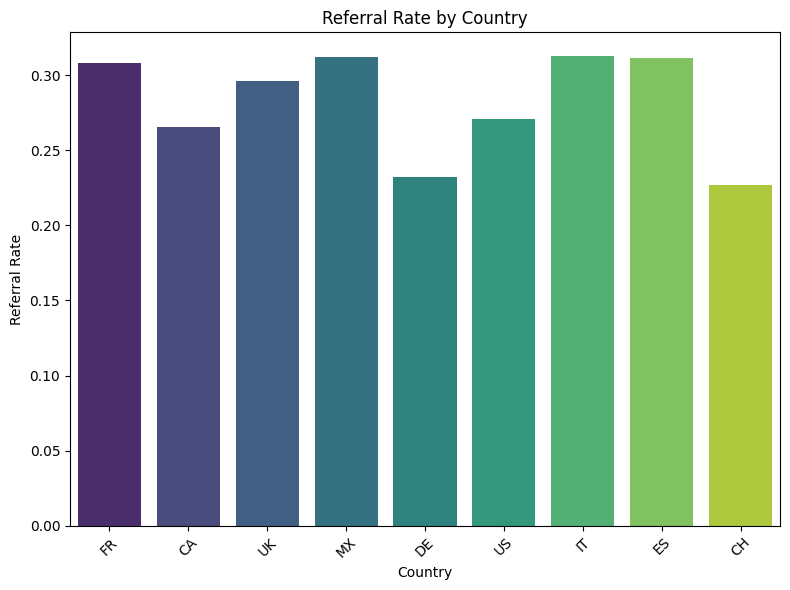

In [22]:
plt.figure(figsize=(8, 6))
sns.barplot(data=referral, x='country', y='is_referral', estimator='mean', errorbar=None, palette='viridis')
plt.title('Referral Rate by Country')
plt.xlabel('Country')
plt.ylabel('Referral Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

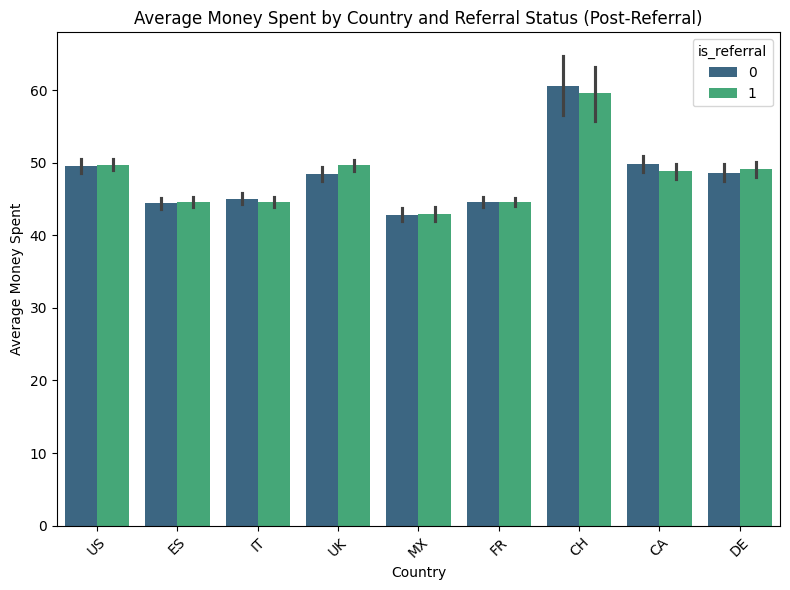

In [18]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df_post, x='country', y='money_spent', hue='is_referral', palette='viridis')
plt.title('Average Money Spent by Country and Referral Status (Post-Referral)')
plt.xlabel('Country')
plt.ylabel('Average Money Spent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Hypothesis 1 — Spend

- H₀: Mean money spent is equal for referral and non-referral users
- H₁: Mean money spent is greater for referral users

In [26]:
referral_spend = df_post[df_post['is_referral']==1]['money_spent']
non_referral_spend = df_post[df_post['is_referral']==0]['money_spent']

# Hypothesis 1


t_stat, p_value = stats.ttest_ind(referral_spend, non_referral_spend, alternative='greater')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀ — Mean money spent is significantly higher for referrals")
else:
    print("Fail to reject H₀ — No significant spend increase detected")


T-statistic: 0.8650
P-value: 0.1935
Fail to reject H₀ — No significant spend increase detected


### H1 Result
##### t=0.865, p=0.19 — Fail to reject H₀
- Referred users show no significant spend advantage over non-referred users.
- The $0.19 incremental spend cannot justify the $10 credit cost.

### Hypothesis 2 — User Growth

- H₀: Mean daily unique users before Oct 31 = mean daily unique users after Oct 31
- H₁: Mean daily unique users increased after Oct 31

In [27]:
pre_daily = df_pre.groupby('date')['user_id'].nunique()
post_daily = df_post.groupby('date')['user_id'].nunique()
# Hypothesis 2
t_stat, p_value = stats.ttest_ind(post_daily, pre_daily, alternative='greater')
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀ — Daily active users significantly increased after launch")
else:
    print("Fail to reject H₀ — No significant increase in daily active users detected")

T-statistic: 1.5864
P-value: 0.0592
Fail to reject H₀ — No significant increase in daily active users detected


#### H2 Result
##### t=1.586, p=0.059 — Fail to reject H₀
- User growth is trending upward post-launch but falls just short of significance.
- Likely a sample size issue — retest at 8-12 weeks for a conclusive result.

#### Hypothesis 3 — Overall Spend Lift

- H₀: Mean money spent per transaction before Oct 31 = after Oct 31
- H₁: Mean money spent per transaction increased after the referral progra

In [28]:
pre_spend = df_pre['money_spent']
post_spend = df_post['money_spent']

t_stat, p_value = stats.ttest_ind(post_spend, pre_spend, alternative='greater')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀ — Overall spend significantly increased after launch")
else:
    print("Fail to reject H₀ — No significant overall spend increase detected")

T-statistic: 30.8977
P-value: 0.0000
Reject H₀ — Overall spend significantly increased after launch


#### H3 Result
##### t=30.89, p≈0.000 — Reject H₀
- Overall spend increased significantly post-launch ($42.39 → $46.96).
- However, both referral and non-referral users lifted equally — seasonality likely the driver, not the program.

#### Confirming the Hypothesis 3 Result by visualizing

In [ ]:
referral['period'] = referral['date']\
        .apply(lambda x: 'Pre-Referral' 
               if x < pd.to_datetime('2015-10-31') else 'Post-Referral')
plt.figure(figsize=(8, 5))
sns.barplot(
    data=referral, 
    x='period', 
    y='money_spent',
    palette='viridis',
    errorbar=None
)
plt.title('Average Money Spent Pre vs Post Referral Launch')
plt.xlabel('Period')
plt.ylabel('Average Money Spent')
plt.tight_layout()
plt.show()

#### Findings
- Overall spend increased significantly post-launch (p≈0.000, +$5 avg), but causality cannot be established without a control group. 
- November seasonality and concurrent factors likely contributed. 
- A properly designed A/B test is required before attributing this lift to the referral program or scaling the $10 credit incentive.

In [35]:
referral_transactions = df_post['is_referral'].sum()
total_credit_cost = referral_transactions * 10

avg_spend_referral = df_post[df_post['is_referral']==1]['money_spent'].mean()
avg_spend_non_referral = df_post[df_post['is_referral']==0]['money_spent'].mean()
avg_spend_pre_referral = df_pre['money_spent'].mean()
incremental_spend = avg_spend_referral - avg_spend_non_referral

print(f"Total referral transactions: {referral_transactions:,.0f}")
print(f"Total credit cost: ${total_credit_cost:,.0f}")
print(f"Avg spend - Pre-referral: ${avg_spend_pre_referral:.2f}")
print(f"Avg spend - Referral users: ${avg_spend_referral:.2f}")
print(f"Avg spend - Non-referral users: ${avg_spend_non_referral:.2f}")
print(f"Incremental spend per referral: ${incremental_spend:.2f}")
print(f"Net per referral transaction: ${incremental_spend - 10:.2f}")

Total referral transactions: 28,015
Total credit cost: $280,150
Avg spend - Pre-referral: $42.39
Avg spend - Referral users: $46.96
Avg spend - Non-referral users: $46.77
Incremental spend per referral: $0.19
Net per referral transaction: $-9.81


#### Findings
- The referral program cost $280,150 in credits during its first month. 
- Referred users spent only $0.19 more per transaction than non-referred users, resulting in a net loss of $9.81 per referral transaction. 
- The program cannot be justified on spend lift alone and requires user retention and lifetime value analysis before scaling.

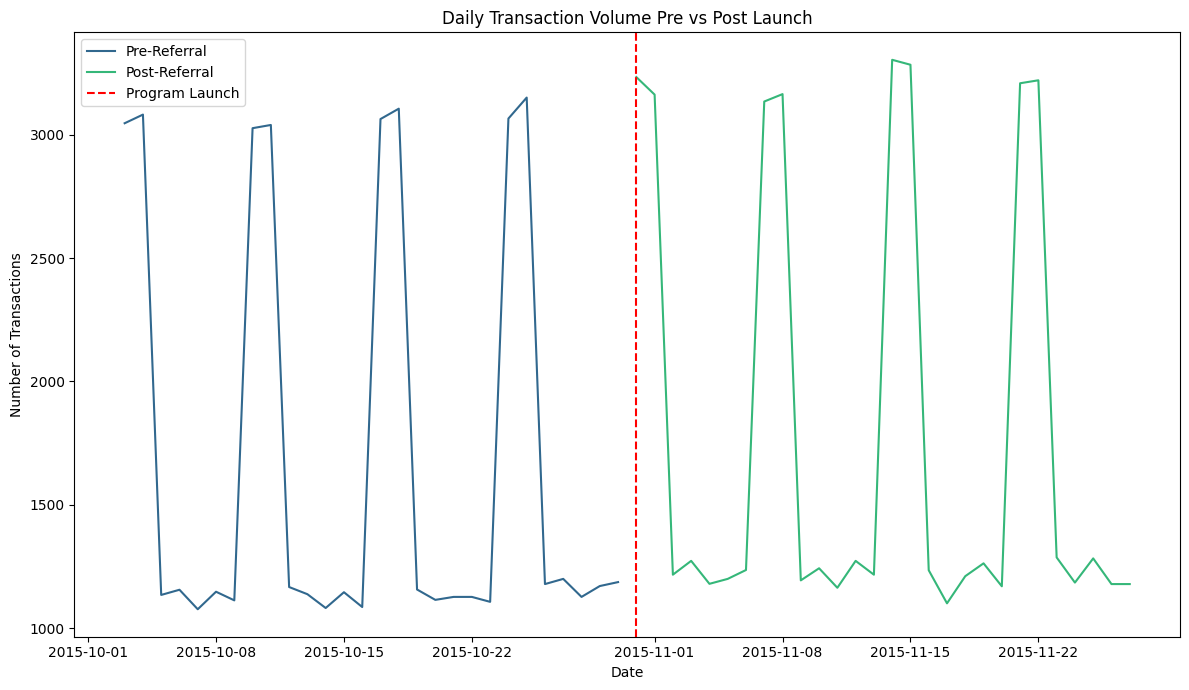

In [41]:
daily_volume = referral.groupby(['date', 'period'])['user_id'].count().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=daily_volume, x='date', y='user_id', hue='period', palette='viridis')
plt.axvline(pd.Timestamp('2015-10-31'), color='red', linestyle='--', label='Program Launch')
plt.title('Daily Transaction Volume Pre vs Post Launch')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Conclusion & Recommendations

### What the Data Tells Us
The referral program launched on October 31, 2015 shows mixed results after its first 
month. Overall platform spend increased significantly post-launch, but the evidence 
suggests external factors such as November seasonality are the primary driver rather 
than the referral program itself. Without a control group, causality cannot be 
established with confidence.

### Key Findings
1. **Spend Lift is Not Referral-Driven** — Referred users spent only $0.19 more per 
   transaction than non-referred users (p=0.19), an economically insignificant difference 
   that cannot justify the $10 credit cost.

2. **Program is Running at a Loss** — Total credit cost reached $280,150 in the first 
   month with a net loss of $9.81 per referral transaction.

3. **User Growth is Promising but Unconfirmed** — Daily unique users trended upward 
   post-launch (p=0.059) but fell just short of statistical significance, likely due to 
   only 4 weeks of post-launch data available.

4. **Overall Spend Lifted Significantly** — Platform-wide avg spend rose from $42.39 to 
   $46.96 (p≈0.000), but since both referral and non-referral users lifted equally, 
   November seasonality is the likely cause, not the program.

5. **Country Insights** — IT, MX, ES, and FR showed the highest referral adoption (~31%). 
   DE and CH underperformed (~23%) despite being high-value markets worth investigating.

### Recommendations
1. **Do not scale the program yet** — The $10 credit incentive is not justified by current 
   spend data alone. Consider reducing it to $5 or making it conditional on the referred 
   user's second purchase to improve unit economics.

2. **Run a proper A/B test** — Assign a randomized control group to isolate the program's 
   true impact from seasonal and external factors. This is the single most important next 
   step before any further investment in the program.

3. **Retest user growth at 8-12 weeks** — The borderline p=0.059 result needs more data 
   to reach a conclusive finding. A longer window will determine if user growth is a real 
   program effect.

4. **Analyze lifetime value** — Referred users may retain better or purchase more 
   frequently over time. LTV analysis could justify the $10 credit even without a 
   per-transaction spend lift. Also examine repeat purchase rates for referred vs 
   non-referred users.

5. **Target high-adoption markets** — Double down on IT, MX, ES, and FR where referral 
   resonance is strongest. Investigate barriers in DE and CH through user research or 
   localized incentive testing.

6. **Test alternative incentive structures** — Explore tiered credits, dual-sided rewards 
   (both referrer and referee receive credit), or non-monetary incentives in the next 
   A/B test to find a structure that improves unit economics without sacrificing growth.